---
title: "Gaussian copula on the residuals — spatial dependence in extremes"
---

# Annual temperature extremes over Spain — part 4: a Gaussian copula on the residuals

Notebooks [01](01_spain_extremes.ipynb)–[03](03_spain_nonstationary.ipynb)
treated stations as **conditionally independent** given the latent fields.
That is fine for the marginals but wrong for **joint** risk: when a heatwave
hits, nearby stations exceed their return levels *together*. This notebook
keeps nb 03's four-GP marginal model and adds a **Gaussian copula** on the
cross-station residuals, with a two-range exponential dependogram

$$R_{ij} = c_0\,e^{-d_{ij}/c_1} + (1 - c_0)\,e^{-d_{ij}/c_2}.$$

Everything reuses the package stack: `xtremax` for the GEV margins
(`gev_cdf`, `gev_icdf`), the distances (`pairwise_distances`) and the
dependogram (`two_range_correlation`); `pyrox.gp` for the latent fields; and
NumPyro SVI. The copula enters the ELBO as a `numpyro.factor`, so $c_0, c_1,
c_2$ are **inferred jointly** with the margins (a step up from the plug-in/IFM
recipe in `jej_vc_snippets/extremes/models/temp_gevd_gp_copula.py`).

## Background — Gaussian copula in three steps

A copula separates marginal behaviour from dependence (Sklar's theorem). With
GEV margins $F_s$ and a Gaussian copula with correlation $R$:

1. **PIT**: $u_{s,t} = F_s(y_{s,t}) \in (0,1)$ — push each observation through
   its own marginal CDF.
2. **To Gaussian scores**: $z_{s,t} = \Phi^{-1}(u_{s,t})$.
3. **Correlate**: the year-$t$ vector $z_{\cdot,t} \sim \mathcal{N}(0, R)$.

The joint log-density is the **sum of marginal GEV log-densities** plus a
**copula correction**

$$\log c(u_{\cdot,t}) = \log \phi_R(z_{\cdot,t}) - \sum_i \log \phi(z_{i,t}),$$

summed over years. We add the marginals via the usual GEV likelihood and the
correction via `numpyro.factor`.

To *simulate* correlated extremes we run Sklar's theorem in reverse:
$z_t \sim \mathcal{N}(0, R^*) \to u_t = \Phi(z_t) \to y_t = F^{-1}(u_t)$.

## Setup

In [1]:
import time

import jax
import jax.numpy as jnp
import jax.random as jr
import jax.scipy.stats as jss
import matplotlib.pyplot as plt
import numpy as np
import optax
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import numpyro
import numpyro.distributions as dist
from numpyro.infer import SVI, Predictive, Trace_ELBO, autoguide
from numpyro.infer.initialization import init_to_value
from jaxtyping import Array, Float
from scipy.stats import genextreme

from pyrox.gp import GPPrior, Matern, gp_sample
from pyrox.gp._src.kernels import matern_kernel
from xtremax import GeneralizedExtremeValueDistribution as GEV
from xtremax import gev_cdf, gev_icdf, gev_return_level, pairwise_distances, two_range_correlation

jax.config.update("jax_enable_x64", True)
EPS_U = 1e-6  # PIT clipping for numerical stability of Phi^{-1}

/home/user/research_notebook/projects/gaussian_processes/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Stations, GMST, pairwise distances (same grid as nbs 02–03)

In [2]:
SPAIN_BBOX = (-9.5, 3.5, 36.0, 43.8)


def _on_land(lon, lat):
    west_of_galicia = (lon < -8.8) & (lat > 42.3)
    below_africa = lat < 36.2
    east_mediterranean = (lon > 2.5) & (lat < 39.0)
    return ~(west_of_galicia | below_africa | east_mediterranean)


def _sample_stations(key, n_target):
    candidates = jr.uniform(
        key, (n_target * 4, 2),
        minval=jnp.array([SPAIN_BBOX[0], SPAIN_BBOX[2]]),
        maxval=jnp.array([SPAIN_BBOX[1], SPAIN_BBOX[3]]),
    )
    return candidates[_on_land(candidates[:, 0], candidates[:, 1])][:n_target]


def synthetic_gmst(years, key):
    t_norm = (years - years[0]) / jnp.maximum(years[-1] - years[0], 1)
    trend = 0.1 + 0.8 * t_norm
    white = 0.05 * jr.normal(key, (years.shape[0],))

    def step(prev, eps):
        cur = 0.6 * prev + eps
        return cur, cur

    _, red = jax.lax.scan(step, white[0], white[1:])
    return trend + jnp.concatenate([white[:1], red])


S = 40
T = 40
YEAR_0 = 1985
YEARS = jnp.arange(YEAR_0, YEAR_0 + T)

key = jr.PRNGKey(2024)
key, key_stations = jr.split(key)
stations = _sample_stations(key_stations, S)
lon_st, lat_st = stations[:, 0], stations[:, 1]
key, key_gmst = jr.split(key)
gmst = synthetic_gmst(YEARS, key_gmst)
d_vec = gmst - jnp.mean(gmst)

D_mat = pairwise_distances(stations)  # xtremax: Euclidean lon/lat distances (S, S)
iu = np.triu_indices(S, k=1)
d_pairs = np.asarray(D_mat)[iu]
print(f"station distance range: {float(D_mat[D_mat > 0].min()):.2f} -> {float(D_mat.max()):.2f} degrees")

station distance range: 0.10 -> 13.01 degrees


## Truth — four latent fields (as nb 03) plus the copula

$\mu(s)$, $\beta(s)$, $\sigma(s)$, $\xi(s)$ exactly as nb 03; the copula adds a
two-range dependogram with $c_0^*=0.5$, $c_1^*=0.5°$ (~55 km, convective) and
$c_2^*=4°$ (~440 km, synoptic).

In [3]:
def draw_from_gp(K, key, jitter=1e-4):
    L = jnp.linalg.cholesky(K + jitter * jnp.eye(K.shape[0]))
    return L @ jr.normal(key, (K.shape[0],))


def _mk(var, ls):
    return matern_kernel(stations, stations, jnp.asarray(var), jnp.asarray(ls), nu=1.5)


TRUTH = {
    "mu0": 35.0, "beta0": 1.2, "logsig0": float(jnp.log(1.8)), "xi0": 0.12,
    "k_mu_var": 4.0, "k_mu_ls": 2.0, "k_beta_var": 0.25, "k_beta_ls": 3.0,
    "k_sig_var": 0.05, "k_sig_ls": 3.0, "k_xi_var": 0.003, "k_xi_ls": 3.0,
    "c0": 0.5, "c1": 0.5, "c2": 4.0,
}

key, *subs = jr.split(key, 5)
mu_truth = draw_from_gp(_mk(TRUTH["k_mu_var"], TRUTH["k_mu_ls"]), subs[0])
beta_truth = TRUTH["beta0"] + draw_from_gp(_mk(TRUTH["k_beta_var"], TRUTH["k_beta_ls"]), subs[1])
logsig_truth = TRUTH["logsig0"] + draw_from_gp(_mk(TRUTH["k_sig_var"], TRUTH["k_sig_ls"]), subs[2])
xi_truth = TRUTH["xi0"] + draw_from_gp(_mk(TRUTH["k_xi_var"], TRUTH["k_xi_ls"]), subs[3])
sigma_truth = jnp.exp(logsig_truth)
f_truth = TRUTH["mu0"] + mu_truth[:, None] + beta_truth[:, None] * d_vec[None, :]  # (S, T)

# True copula correlation (xtremax two-range dependogram, valid correlation matrix)
R_truth = two_range_correlation(D_mat, TRUTH["c0"], TRUTH["c1"], TRUTH["c2"])
print(f"R* PD check: min eigval = {float(jnp.linalg.eigvalsh(R_truth).min()):.3e}")

R* PD check: min eigval = 9.946e-02


### Inverse-PIT simulation — correlated extremes via Sklar

$z_t \sim \mathcal{N}(0, R^*)$, $u_t = \Phi(z_t)$, $y_t = F^{-1}_{\rm GEV}(u_t)$
with the per-station margins. Uses `xtremax.gev_icdf`.

In [4]:
L_truth = jnp.linalg.cholesky(R_truth)
key, key_z = jr.split(key)
z_truth = jr.normal(key_z, (T, S)) @ L_truth.T   # (T, S) correlated normals
u_truth = jss.norm.cdf(z_truth)                  # (T, S)
y_obs = gev_icdf(
    jnp.clip(u_truth.T, EPS_U, 1.0 - EPS_U),     # (S, T)
    f_truth, sigma_truth[:, None], xi_truth[:, None],
)
Y_MEAN = float(jnp.mean(y_obs))
print(f"y_obs shape: {y_obs.shape}  range: [{float(y_obs.min()):.1f}, {float(y_obs.max()):.1f}] °C")

# Verify xtremax GEV margins vs scipy
y_grid = jnp.linspace(-2.0, 25.0, 60)
ours = GEV(loc=3.0, scale=1.5, concentration=0.2).log_prob(y_grid)
theirs = genextreme.logpdf(np.asarray(y_grid), c=-0.2, loc=3.0, scale=1.5)
print(f"xtremax GEV vs scipy (ξ=0.2)  max|Δ| = {float(jnp.max(jnp.abs(ours - theirs))):.2e}")

y_obs shape: (40, 40)  range: [28.1, 60.1] °C


xtremax GEV vs scipy (ξ=0.2)  max|Δ| = 5.12e-13


### Inspect the truth — four fields + the copula dependogram

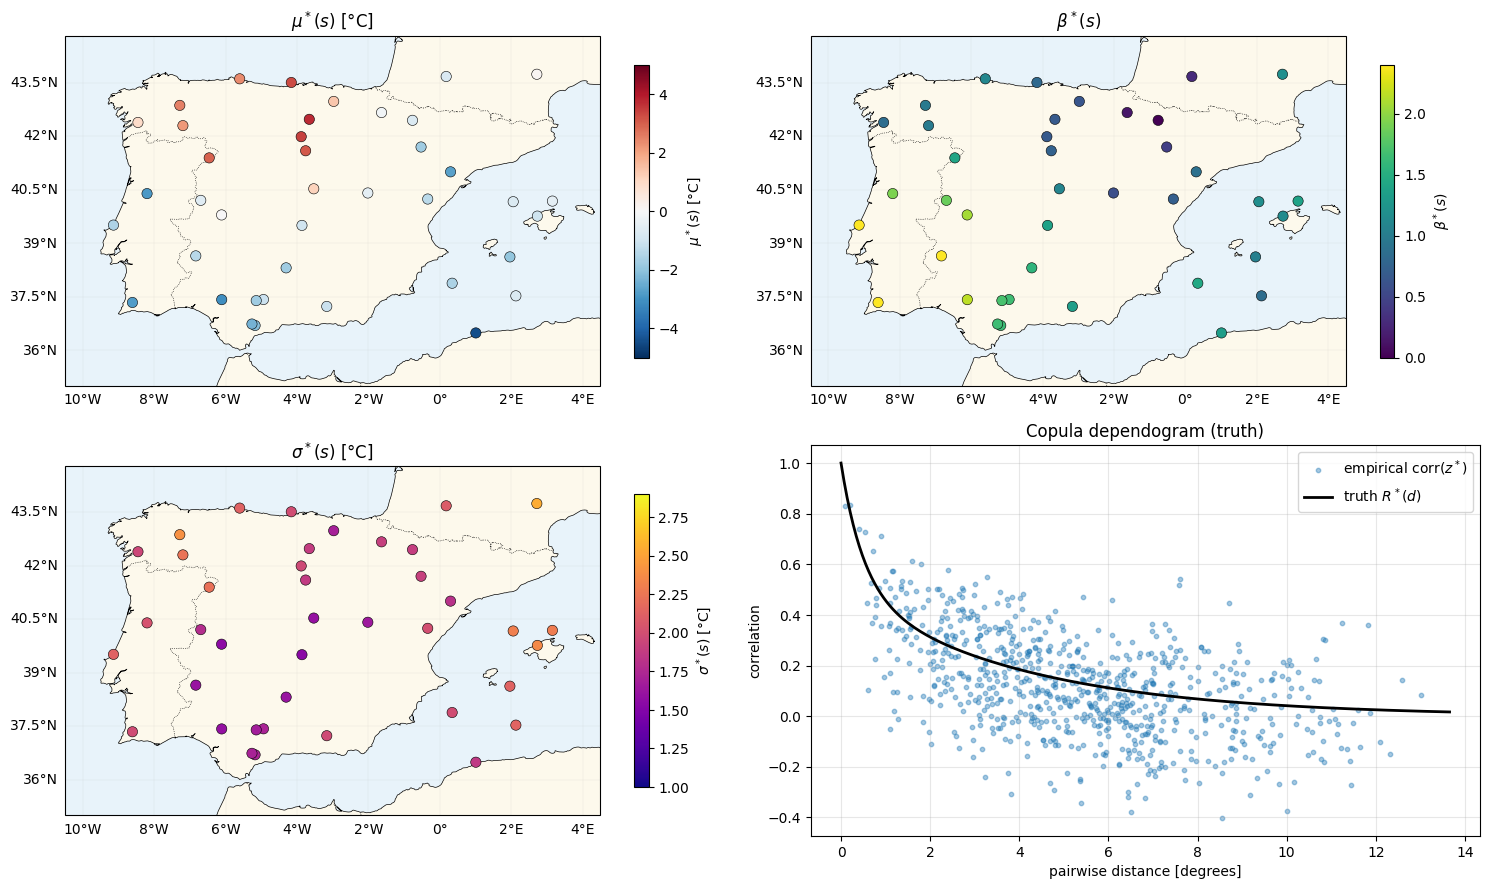

In [5]:
def plot_stations(ax, values, *, cmap, vlim, label):
    ax.set_extent([SPAIN_BBOX[0] - 1, SPAIN_BBOX[1] + 1, SPAIN_BBOX[2] - 1, SPAIN_BBOX[3] + 1], crs=ccrs.PlateCarree())
    ax.add_feature(cfeature.COASTLINE, linewidth=0.5)
    ax.add_feature(cfeature.BORDERS, linestyle=":", linewidth=0.5)
    ax.add_feature(cfeature.OCEAN, facecolor="#e8f3fa")
    ax.add_feature(cfeature.LAND, facecolor="#fdf9ec")
    sc = ax.scatter(
        np.asarray(lon_st), np.asarray(lat_st), c=np.asarray(values), cmap=cmap,
        vmin=vlim[0], vmax=vlim[1], s=55, edgecolors="k", linewidths=0.4,
        transform=ccrs.PlateCarree(), zorder=5,
    )
    gl = ax.gridlines(draw_labels=True, linewidth=0.2, alpha=0.4)
    gl.top_labels = gl.right_labels = False
    plt.colorbar(sc, ax=ax, shrink=0.75, label=label)


fig = plt.figure(figsize=(15, 9))
specs = [
    (1, mu_truth, "RdBu_r", (-5, 5), r"$\mu^*(s)$ [°C]"),
    (2, beta_truth, "viridis", (0.0, 2.4), r"$\beta^*(s)$"),
    (3, sigma_truth, "plasma", (1.0, 2.9), r"$\sigma^*(s)$ [°C]"),
]
for idx, vals, cmap, vlim, label in specs:
    ax = fig.add_subplot(2, 2, idx, projection=ccrs.PlateCarree())
    plot_stations(ax, vals, cmap=cmap, vlim=vlim, label=label)
    ax.set_title(label)
# 4th panel: the dependogram (truth curve + empirical corr of the true z)
ax_dep = fig.add_subplot(2, 2, 4)
emp_corr_truth = np.asarray(jnp.corrcoef(z_truth.T))[iu]
d_grid = np.linspace(0, float(D_mat.max()) * 1.05, 200)
r_curve = TRUTH["c0"] * np.exp(-d_grid / TRUTH["c1"]) + (1 - TRUTH["c0"]) * np.exp(-d_grid / TRUTH["c2"])
ax_dep.scatter(d_pairs, emp_corr_truth, s=10, alpha=0.4, color="C0", label=r"empirical corr$(z^*)$")
ax_dep.plot(d_grid, r_curve, "k-", lw=2, label=r"truth $R^*(d)$")
ax_dep.set_xlabel("pairwise distance [degrees]")
ax_dep.set_ylabel("correlation")
ax_dep.set_title("Copula dependogram (truth)")
ax_dep.legend()
ax_dep.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## Model — nb 03 four-GP marginals + a Gaussian copula factor

The four `pyrox` spatial GPs and the `xtremax` GEV margins are exactly nb 03.
Three extra scalars $(c_0, c_1, c_2)$ parameterise the dependogram, and a
`numpyro.factor` adds the per-year copula correction
$\log\phi_R(z_t) - \sum_i \log\phi(z_{i,t})$.

In [6]:
def _kernel(name, var, ls):
    k = Matern(pyrox_name=name, nu=1.5)
    k.set_prior("variance", dist.LogNormal(jnp.log(var), 0.5))
    k.set_prior("lengthscale", dist.LogNormal(jnp.log(ls), 0.5))
    return k


def model(stations, dist_mat, d_vec, y=None):
    mu_s = gp_sample("mu_s", GPPrior(kernel=_kernel("k_mu", 2.0, 2.0), X=stations), whitened=True)
    beta_tilde = gp_sample("beta_tilde", GPPrior(kernel=_kernel("k_beta", 0.2, 3.0), X=stations), whitened=True)
    sig_r = gp_sample("sig_r", GPPrior(kernel=_kernel("k_sig", 0.05, 3.0), X=stations), whitened=True)
    xi_r = gp_sample("xi_r", GPPrior(kernel=_kernel("k_xi", 0.003, 3.0), X=stations), whitened=True)
    mu_s = mu_s - jnp.mean(mu_s)
    beta_tilde = beta_tilde - jnp.mean(beta_tilde)
    sig_r = sig_r - jnp.mean(sig_r)
    xi_r = xi_r - jnp.mean(xi_r)

    mu0 = numpyro.sample("mu0", dist.Normal(Y_MEAN, 5.0))
    beta0 = numpyro.sample("beta0", dist.Normal(1.0, 0.5))
    logsig0 = numpyro.sample("logsig0", dist.Normal(jnp.log(1.8), 0.3))
    xi0 = numpyro.sample("xi0", dist.Normal(0.1, 0.1))
    # Copula dependogram scalars: mixing weight + two ranges (short, long).
    c0 = numpyro.sample("c0", dist.Beta(2.0, 2.0))
    c1 = numpyro.sample("c1", dist.LogNormal(jnp.log(0.5), 0.4))
    c2 = numpyro.sample("c2", dist.LogNormal(jnp.log(4.0), 0.4))

    sigma_s = jnp.exp(logsig0 + sig_r)
    xi_s = xi0 + xi_r
    beta_s = beta0 + beta_tilde
    loc = mu0 + mu_s[:, None] + beta_s[:, None] * d_vec[None, :]

    numpyro.deterministic("mu_field", mu_s)
    numpyro.deterministic("beta_field", beta_s)
    numpyro.deterministic("sigma_field", sigma_s)
    numpyro.deterministic("xi_field", xi_s)
    # Marginal GEV likelihood
    numpyro.sample("y", GEV(loc=loc, scale=sigma_s[:, None], concentration=xi_s[:, None]), obs=y)

    if y is not None:
        # Gaussian-copula correction at the GEV margins (full joint inference).
        u = jnp.clip(gev_cdf(y, loc, sigma_s[:, None], xi_s[:, None]), EPS_U, 1.0 - EPS_U)  # (S, T)
        z = dist.Normal(0.0, 1.0).icdf(u)  # (S, T)
        R = two_range_correlation(dist_mat, c0, c1, c2)  # (S, S)
        mvn = dist.MultivariateNormal(loc=jnp.zeros(S), covariance_matrix=R)
        # per year: log phi_R(z_t) - sum_i log phi(z_{i,t})
        corr = jax.vmap(mvn.log_prob)(z.T) - jnp.sum(dist.Normal(0.0, 1.0).log_prob(z.T), axis=-1)
        numpyro.factor("copula", corr.sum())

## Inference — SVI (whitened GP bases initialised at zero, as nb 03)

In [7]:
zeros_S = jnp.zeros(S)
guide = autoguide.AutoNormal(
    model,
    init_loc_fn=init_to_value(values={
        "mu_s_u": zeros_S, "beta_tilde_u": zeros_S, "sig_r_u": zeros_S, "xi_r_u": zeros_S,
        "mu0": Y_MEAN, "beta0": 1.0, "logsig0": float(jnp.log(1.8)), "xi0": 0.1,
        "c0": 0.5, "c1": 1.0, "c2": 2.0,
    }),
)
optimizer = numpyro.optim.optax_to_numpyro(
    optax.chain(optax.zero_nans(), optax.clip_by_global_norm(10.0), optax.adam(3e-3))
)
svi = SVI(model, guide, optimizer, Trace_ELBO())

t0 = time.time()
svi_result = svi.run(jr.PRNGKey(0), 8000, stations, D_mat, d_vec, y_obs, progress_bar=False)
losses = np.asarray(svi_result.losses)
post = Predictive(model, guide=guide, params=svi_result.params, num_samples=600)(
    jr.PRNGKey(3), stations, D_mat, d_vec
)
lat = guide.sample_posterior(jr.PRNGKey(4), svi_result.params, sample_shape=(600,))
print(f"SVI finished in {time.time() - t0:.1f}s")

c0_fit, c1_fit, c2_fit = float(lat["c0"].mean()), float(lat["c1"].mean()), float(lat["c2"].mean())
print(f"fitted μ₀={float(lat['mu0'].mean()):.2f}(35)  β₀={float(lat['beta0'].mean()):.2f}  "
      f"σ₀={float(jnp.exp(lat['logsig0'].mean())):.2f}  ξ₀={float(lat['xi0'].mean()):.3f}")
print(f"fitted c0={c0_fit:.3f}(0.5)  c1={c1_fit:.3f}(0.5)  c2={c2_fit:.3f}(4.0)  [degrees]")

SVI finished in 44.1s
fitted μ₀=34.66(35)  β₀=1.36  σ₀=1.81  ξ₀=0.103
fitted c0=0.526(0.5)  c1=0.433(0.5)  c2=3.420(4.0)  [degrees]


### Loss curve

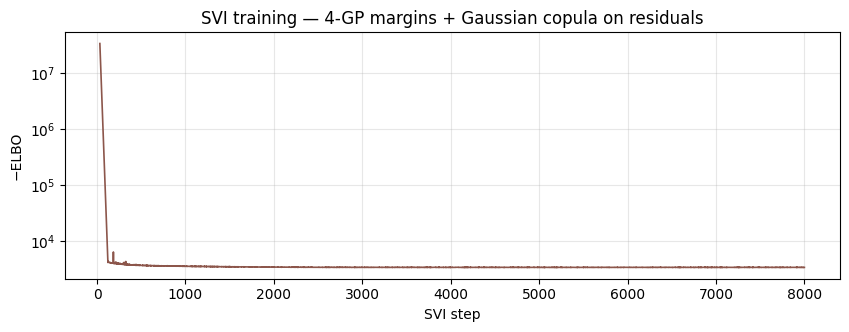

In [8]:
fig, ax = plt.subplots(figsize=(10, 3.2))
finite = np.isfinite(losses)
ax.plot(np.arange(len(losses))[finite], losses[finite], "C5-", lw=1.2)
ax.set_xlabel("SVI step")
ax.set_ylabel("−ELBO")
ax.set_yscale("symlog", linthresh=100.0)
ax.set_title("SVI training — 4-GP margins + Gaussian copula on residuals")
ax.grid(alpha=0.3, which="both")
plt.show()

## Recovery of the four latent fields

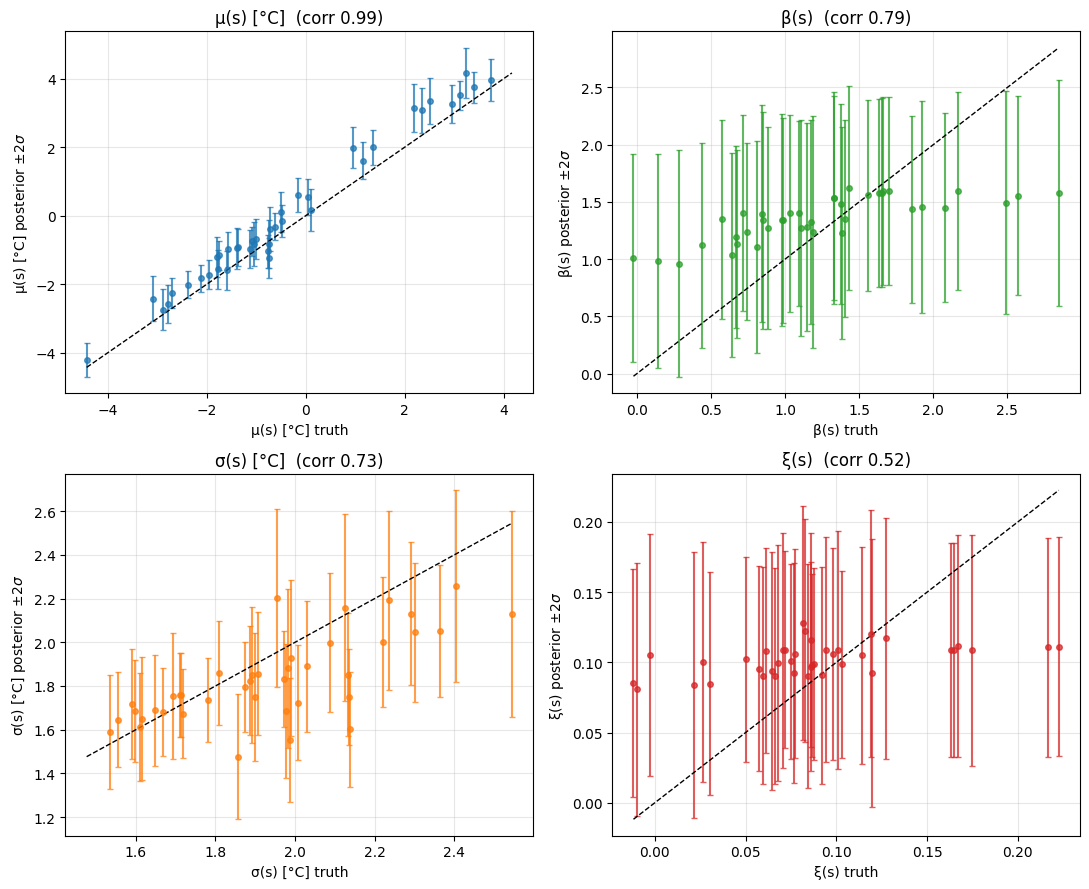

In [9]:
mu_mean = post["mu_field"].mean(0)
beta_mean = post["beta_field"].mean(0)
sig_mean = post["sigma_field"].mean(0)
xi_mean = post["xi_field"].mean(0)


def _corr(a, b):
    return float(np.corrcoef(np.asarray(a), np.asarray(b))[0, 1])


fields = [
    ("μ(s) [°C]", mu_mean, post["mu_field"].std(0), mu_truth, "C0"),
    ("β(s)", beta_mean, post["beta_field"].std(0), beta_truth, "C2"),
    ("σ(s) [°C]", sig_mean, post["sigma_field"].std(0), sigma_truth, "C1"),
    ("ξ(s)", xi_mean, post["xi_field"].std(0), xi_truth, "C3"),
]
fig, axes = plt.subplots(2, 2, figsize=(11, 9))
for ax, (name, fit, sd, truth, c) in zip(axes.flat, fields, strict=True):
    ax.errorbar(np.asarray(truth), np.asarray(fit), yerr=2 * np.asarray(sd),
                fmt="o", color=c, ms=4, alpha=0.75, capsize=2)
    lo = float(min(np.min(truth), np.min(fit)))
    hi = float(max(np.max(truth), np.max(fit)))
    ax.plot([lo, hi], [lo, hi], "k--", lw=1)
    ax.set_xlabel(f"{name} truth")
    ax.set_ylabel(rf"{name} posterior $\pm 2\sigma$")
    ax.set_title(f"{name}  (corr {_corr(fit, truth):.2f})")
    ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## The killer plot — copula recovery

Three curves should agree on a single dependogram: the **truth** $R^*(d)$, the
**empirical** residual correlation of $\hat z = \Phi^{-1}(F_{\hat\theta}(y))$
(the model's own margins applied to the data), and the **fitted** parametric
$\hat R(d)$.

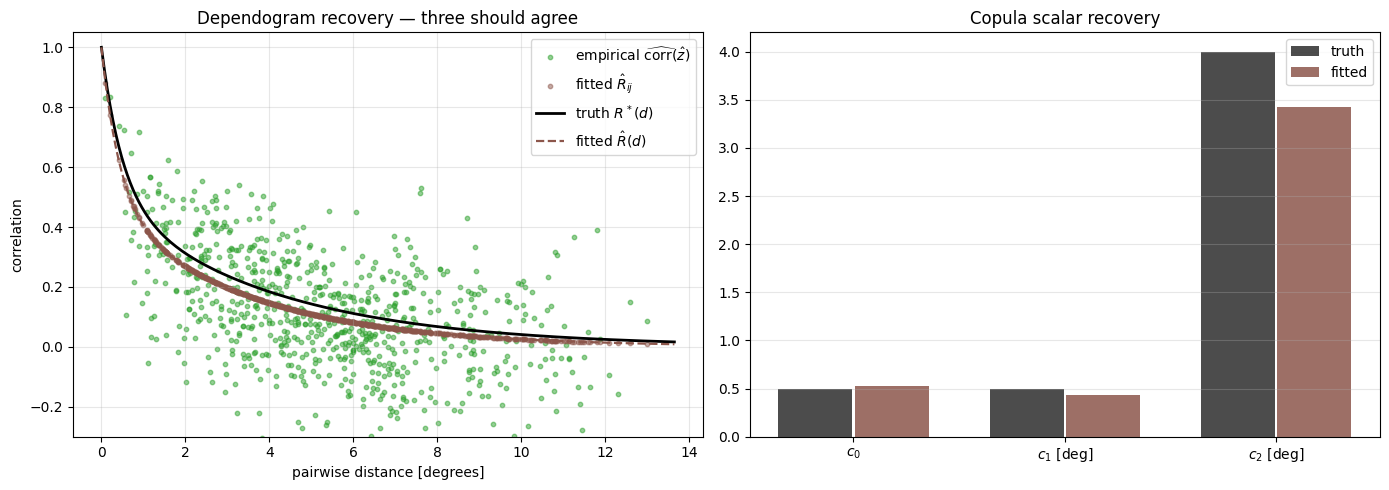

In [10]:
tau_post = float(lat["mu0"].mean()) + mu_mean[:, None] + beta_mean[:, None] * d_vec[None, :]
u_hat = jnp.clip(gev_cdf(y_obs, tau_post, sig_mean[:, None], xi_mean[:, None]), EPS_U, 1.0 - EPS_U)
z_hat = jss.norm.ppf(u_hat)
emp_pairs_hat = np.asarray(jnp.corrcoef(z_hat))[iu]
R_fit = two_range_correlation(D_mat, c0_fit, c1_fit, c2_fit)
fit_pairs = np.asarray(R_fit)[iu]

truth_curve = TRUTH["c0"] * np.exp(-d_grid / TRUTH["c1"]) + (1 - TRUTH["c0"]) * np.exp(-d_grid / TRUTH["c2"])
fit_curve = c0_fit * np.exp(-d_grid / c1_fit) + (1 - c0_fit) * np.exp(-d_grid / c2_fit)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
ax = axes[0]
ax.scatter(d_pairs, emp_pairs_hat, s=10, alpha=0.5, color="C2", label=r"empirical $\widehat{\mathrm{corr}}(\hat z)$")
ax.scatter(d_pairs, fit_pairs, s=10, alpha=0.5, color="C5", label=r"fitted $\hat R_{ij}$")
ax.plot(d_grid, truth_curve, "k-", lw=2, label=r"truth $R^*(d)$")
ax.plot(d_grid, fit_curve, "C5--", lw=1.6, label=r"fitted $\hat R(d)$")
ax.set_xlabel("pairwise distance [degrees]")
ax.set_ylabel("correlation")
ax.set_title("Dependogram recovery — three should agree")
ax.legend()
ax.grid(alpha=0.3)
ax.set_ylim(-0.3, 1.05)

ax = axes[1]
labels = [r"$c_0$", r"$c_1$ [deg]", r"$c_2$ [deg]"]
x = np.arange(3)
ax.bar(x - 0.18, [TRUTH["c0"], TRUTH["c1"], TRUTH["c2"]], width=0.35, color="k", alpha=0.7, label="truth")
ax.bar(x + 0.18, [c0_fit, c1_fit, c2_fit], width=0.35, color="C5", alpha=0.85, label="fitted")
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.set_title("Copula scalar recovery")
ax.legend()
ax.grid(alpha=0.3, axis="y")
plt.tight_layout()
plt.show()

## Joint exceedance probabilities — where the copula visibly wins

Probability that the **5 most central stations** all exceed their own 25-year
return level in the same year. Under conditional independence this is
$(1/25)^5 \approx 10^{-7}$; under the fitted copula it is
$\Pr(\bigcap_i Z_i > \Phi^{-1}(1-p))$ with $Z \sim \mathcal{N}(0, R_I)$.

In [11]:
centre = jnp.array([(SPAIN_BBOX[0] + SPAIN_BBOX[1]) / 2, (SPAIN_BBOX[2] + SPAIN_BBOX[3]) / 2])
core_idx = jnp.argsort(jnp.sqrt(jnp.sum((stations - centre[None, :]) ** 2, axis=1)))[:5]
p = 1.0 / 25.0
threshold_z = float(jss.norm.ppf(1.0 - p))
prob_indep = p ** len(core_idx)

R_I = R_fit[jnp.ix_(core_idx, core_idx)]
key, key_mc = jr.split(key)
Z_mc = jr.normal(key_mc, (200_000, len(core_idx))) @ jnp.linalg.cholesky(R_I).T
prob_copula = float(jnp.mean(jnp.all(Z_mc > threshold_z, axis=1)))

core_thresholds = np.asarray(gev_icdf(jnp.asarray(1.0 - p), tau_post[core_idx, :],
                                      sig_mean[core_idx, None], xi_mean[core_idx, None]))
y_np = np.asarray(y_obs)[np.asarray(core_idx), :]
exceed_emp = int(np.sum(np.all(y_np > core_thresholds, axis=0)))

print("Pr(all 5 central stations exceed their 25-yr return level in the same year):")
print(f"  conditional independence (nb 03):  {prob_indep:.2e}")
print(f"  fitted Gaussian copula (MC):       {prob_copula:.2e}   ({prob_copula / prob_indep:.0f}x larger)")
print(f"  observed in {T} years:             {exceed_emp / T:.2e}  ({exceed_emp}/{T} years)")

Pr(all 5 central stations exceed their 25-yr return level in the same year):
  conditional independence (nb 03):  1.02e-07
  fitted Gaussian copula (MC):       7.50e-05   (732x larger)
  observed in 40 years:             0.00e+00  (0/40 years)


## Summary

- The four-GP marginal model from nb 03 is unchanged; the copula adds three
  scalars and a per-year `numpyro.factor` correction
  $\log\phi_R(z_t) - \sum_i\log\phi(z_{i,t})$ — so $c_0, c_1, c_2$ are inferred
  **jointly** with the margins (full variational inference, not plug-in/IFM).
- The dependogram is built with `xtremax.two_range_correlation` and the
  distances with `xtremax.pairwise_distances`; PIT and its inverse use
  `xtremax.gev_cdf` / `gev_icdf`. The two-range form
  $R_{ij} = c_0 e^{-d/c_1} + (1-c_0) e^{-d/c_2}$ separates a convective range
  $c_1$ from a synoptic range $c_2$.
- Empirical residual correlation, fitted $\hat R(d)$, and truth $R^*(d)$ line
  up — the copula recovers both the parametric form and the empirical structure.
- On **joint** return periods the copula gives a probability orders of
  magnitude larger than the conditional-independence approximation — the
  correction that matters for compound climate risk.

### Follow-ups

- **Reparameterised-MC copula** instead of the margin plug-in inside the factor.
- **Non-stationary copula** $R(d, s)$ for region-specific dependence regimes
  (Atlantic vs continental vs Mediterranean).
- **Tail-dependent copulas** (Student-$t$, Gumbel) — the Gaussian copula is
  asymptotically tail-independent, so it understates the tendency of the most
  extreme heatwaves to synchronise across regions.